# in silico ChIP at single-cell resolution

In [1]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
})
source('../insilico_chip/utils.R')

In [8]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'

## All single-cells
io$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
io$ATAC_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
io$meta = file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
#
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")


In [21]:
unique(meta_in$celltype)

[1] NA                               "Mixed_mesoderm"                
 [3] "Primitive_Streak"               "Somitic_mesoderm"              
 [5] "Gut"                            "Caudal_epiblast"               
 [7] "Blood_progenitors_1"            "Rostral_neurectoderm"          
 [9] "Visceral_endoderm"              "ExE_endoderm"                  
[11] "ExE_ectoderm"                   "Nascent_mesoderm"              
[13] "Haematoendothelial_progenitors" "Def._endoderm"                 
[15] "Caudal_Mesoderm"                "Epiblast"                      
[17] "Mesenchyme"                     "Blood_progenitors_2"           
[19] "Paraxial_mesoderm"              "Anterior_Primitive_Streak"     
[21] "Pharyngeal_mesoderm"            "Surface_ectoderm"              
[23] "Notochord"                      "Intermediate_mesoderm"         
[25] "Parietal_endoderm"              "PGC"                           
[27] "ExE_mesoderm"                   "Forebrain_Midbrain_Hindbrain"  
[29] "Spinal_cord"                    "Caudal_neurectoderm"           
[31] "Allantois"                      "Endothelium"                   
[33] "Neural_crest"                   "Cardiomyocytes"                
[35] "Erythroid1"                     "NMP"                           
[37] "Erythroid2"                     "Erythroid3"

In [14]:
opts = list()
opts$celltype.colors = c(
  "Epiblast" = "#635547",
  "Primitive_Streak" = "#DABE99",
  "Caudal_epiblast" = "#9e6762",
  "PGC" = "#FACB12",
  "Anterior_Primitive_Streak" = "#c19f70",
  "Notochord" = "#0F4A9C",
  "Def._endoderm" = "#F397C0",
  "Gut" = "#EF5A9D",
  "Nascent_mesoderm" = "#C594BF",
  "Mixed_mesoderm" = "#DFCDE4",
  "Intermediate_mesoderm" = "#139992",
  "Caudal_Mesoderm" = "#3F84AA",
  "Paraxial_mesoderm" = "#8DB5CE",
  "Somitic_mesoderm" = "#005579",
  "Pharyngeal_mesoderm" = "#C9EBFB",
  "Cardiomyocytes" = "#B51D8D",
  "Allantois" = "#532C8A",
  "ExE_mesoderm" = "#8870ad",
  "Mesenchyme" = "#cc7818",
  "Haematoendothelial_progenitors" = "#FBBE92",
  "Endothelium" = "#ff891c",
  "Blood_progenitors" = "#c9a997",
  "Blood_progenitors_1" = "#f9decf",
  "Blood_progenitors_2" = "#c9a997",
  "Erythroid" = "#EF4E22",
  "Erythroid1" = "#C72228",
  "Erythroid2" = "#f79083",
  "Erythroid3" = "#EF4E22",
  "NMP" = "#8EC792",
  "Neurectoderm" = "#65A83E",
  "Rostral_neurectoderm" = "#65A83E",
  "Caudal_neurectoderm" = "#354E23",
  "Neural_crest" = "#C3C388",
  "Forebrain_Midbrain_Hindbrain" = "#647a4f",
  "Spinal_cord" = "#CDE088",
  "Surface_ectoderm" = "#f7f79e",
  "Visceral_endoderm" = "#F6BFCB",
  "ExE_endoderm" = "#7F6874",
  "ExE_ectoderm" = "#989898",
  "Parietal_endoderm" = "#1A1A1A"
)

In [3]:
### Define functions specific for Single-cell analysis
tfidf <- function(mtx, method = 1, scale.factor = 1e4) {
  npeaks <- colSums(mtx)
  if (any(npeaks == 0)) {
    warning("Some cells contain 0 total counts")
  }

  tf <- Matrix::tcrossprod(mtx, y = Matrix::Diagonal(x=1/npeaks))

  rsums <- rowSums(mtx)
  if (any(rsums == 0)) {
    warning("Some features contain 0 total counts")
  }
  idf <- ncol(mtx) / rsums

  if (method == 2) {
    idf <- log(1 + idf)
  } else if (method == 3) {
    tf <- log1p(tf * scale.factor)
    idf <- log(1 + idf)
  }
  mtx.tfidf <- Matrix::Diagonal(n = length(idf), x = idf) %*% tf

  if (method == 1) {
    mtx.tfidf <- log1p(mtx.tfidf * scale.factor)
  }
  colnames(mtx.tfidf) <- colnames(mtx)
  rownames(mtx.tfidf) <- rownames(mtx)

  # set NA values to 0
  mtx.tfidf[is.na(mtx.tfidf)] <- 0

  return(mtx.tfidf)
}

pdist <- function(tmat){
  mtm <- Matrix::tcrossprod(tmat)
  sq <- rowSums(tmat^2)
  out0 <- outer(sq, sq, "+") - 2 * mtm
  out0[out0 < 0] <- 0
  
  sqrt(out0)
}

smooth = function(mat, neighbours, ncores=detectCores()/2){
    tmp = mclapply(1:dim(mat)[2], function(x){
        tmp2 = Matrix::rowMeans(round(mat[,neighbours[x,]]))
    }, mc.cores=ncores) 
    names(tmp) = colnames(mat)    
    tmp = bind_cols(tmp)
    tmp = as(as.matrix(tmp), 'sparseMatrix')
    rownames(tmp) = rownames(mat)
    return(tmp)
}

In [27]:

#######################
## Load RNA and ATAC 
#######################
meta_in = fread(io$meta) %>% 
    .[!is.na(celltype)]

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Make sure that samples are consistent
samples <- intersect(intersect(colnames(rna.sce),colnames(atac.sce)), 
                     rownames(colData(rna.sce)[!colData(rna.sce)$sample %in% c('E8.5_CRISPR_T_WT', 'E8.5_CRISPR_T_KO'),])) # remove T KO/WT
samples <- intersect(samples, meta_in$cell)
rna.sce <- rna.sce[,samples]
atac.sce <- atac.sce[,samples]

print(sprintf("Number of cells: %s",length(samples)))

# Normalise RNA data
rna.sce = logNormCounts(rna.sce)

# Normalise ATAC data
assayNames(atac.sce) <- "counts"
assay(atac.sce,"logcounts") <- tfidf(assay(atac.sce,"counts"))

[1] "Number of cells: 45831"


In [35]:
length(samples)

[1] 45831

In [37]:
peak = 'chr4:115048083-115048683'
meta = data.table(celltype = meta_in[match(samples, cell),]$celltype,
                  expression = as.vector(assay(rna.sce['Tal1',], 'logcounts')),
                  accessibility = as.vector(assay(atac.sce[peak, ], 'logcounts')))

`geom_smooth()` using formula = 'y ~ x'


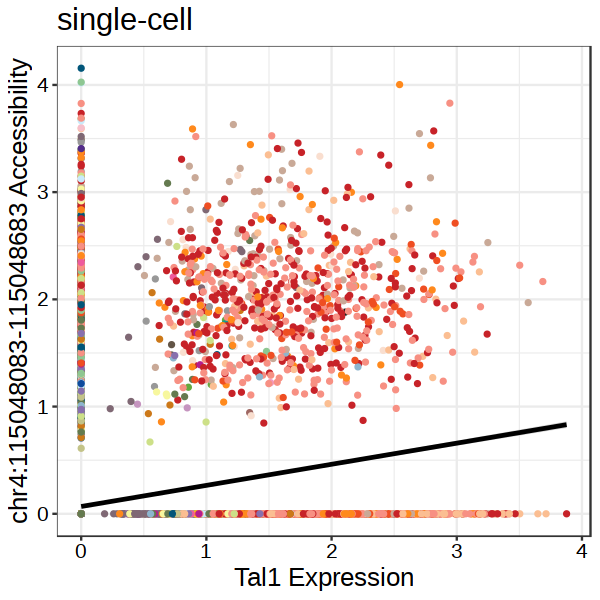

In [38]:
options(repr.plot.height=5, repr.plot.width=5)
ggplot(meta, aes(expression, accessibility)) + 
    geom_smooth(method='lm', color='black') + 
    geom_point(aes(color=celltype), size=1) + 
    scale_color_manual(values=opts$celltype.colors) + 
    xlab('Tal1 Expression') + ylab(sprintf('%s Accessibility', peak)) + 
    ggtitle('single-cell') + 
    theme_bw() + 
    theme(text=element_text(size=15, color='black'),
          legend.position='none',
         axis.text=element_text(color='black'))

In [104]:
# # Imputation
# pca.rna = fread(file.path(io$basedir, 'results/rna/dimensionality_reduction/cells/sce/batch_correction_sample_remove_ExE_cells_False/pca_features2500_pcs50.txt.gz')) %>% 
#    # .[match(samples, cell)] %>%
#     .[!is.na(cell)] %>%
#     matrix.please
# summary(samples %in% rownames(pca.rna))

# # Imputation
# pca.rna = fread(file.path(io$basedir, 'results/rna/dimensionality_reduction/cells/sce/batch_correction_sample_remove_ExE_cells_False/pca_features2500_pcs50.txt.gz')) %>% 
#     .[match(samples, cell)] %>%
#     matrix.please

# NN = BiocNeighbors::queryKNN(pca.rna, pca.rna, k=15)

# a = Sys.time()
# assay(atac.sce,"logcounts_smooth") = smooth(logcounts(rna.sce), NN$index, ncores=detectCores()-2)
# b = Sys.time()
# b - a 

# # Imputation
# lsi.atac = fread(file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_False/batch_correction_sample/lsi_nfeatures25000_ndims50.txt.gz')) %>% 
#     matrix.please

# NN = BiocNeighbors::queryKNN(lsi.atac, lsi.atac, k=15)

# a = Sys.time()
# assay(atac.sce,"logcounts_smooth") = smooth(logcounts(atac.sce), NN$index, ncores=detectCores()-2)
# b = Sys.time()
# b - a 

   Mode   FALSE    TRUE 
logical    4157   57729 

In [125]:
# # RNA dimreduction

# decomp <- modelGeneVar(rna.sce)
# decomp <- decomp[decomp$mean > 0.01,]
# hvgs <- decomp[order(decomp$FDR),] %>% head(n=2000) %>% rownames

# sce_filt <- rna.sce[hvgs,]
# sce_filt <- runPCA(sce_filt, ncomponents = 20, ntop=2000)

# sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 20, min_dist = 1.5)

# umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
#   .[,cell:=colnames(sce_filt)] %>%
#   setnames(c("UMAP1","UMAP2","cell"))

# options(repr.plot.width=5, repr.plot.height=4)
# gene = 'Gata2'
# ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
#     geom_point() +
#     viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
#     ggtitle(paste0(gene, ' - Expression')) + 
#     theme_void()

In [39]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [40]:
summary(colnames(rna.sce) == colnames(atac.sce))

   Mode    TRUE 
logical   45831 

In [41]:
cor_TF_acc = function(rna.sce, 
                      atac.sce, 
                      TFs_filt = NULL,
                      motifmatcher.se = motifmatcher.se, 
                      motif2gene.dt = motif2gene.dt,
                      correlation_method = "pearson", 
                      remove_motifs = c("T_789"),
                      cores = detectCores()){

    if(is.null(motifmatcher.se)){
        library(motifmatchr)
        stop()
        # to do: 
        # Find motif matches if not supplied
    }

    ###################
    ## Filter TFs 
    ###################

    motifs <- intersect(colnames(motifmatcher.se),motif2gene.dt$motif)
    motifmatcher.se <- motifmatcher.se[,motifs]
    motif2gene.dt <- motif2gene.dt[motif%in%motifs]

    genes <- intersect(toupper(rownames(rna.sce)),motif2gene.dt$gene)
    rna_tf.sce <- rna.sce[str_to_title(genes),]
    rownames(rna_tf.sce) <- toupper(rownames(rna_tf.sce))
    motif2gene.dt <- motif2gene.dt[gene%in%genes]

    # Manually remove some motifs
    if(!is.null(remove_motifs)){
        motif2gene.dt <- motif2gene.dt[!motif %in% remove_motifs]
    }
        
    # Remove duplicated gene-motif pairs
    genes.to.remove <- names(which(table(motif2gene.dt$gene)>1))
    print(sprintf("Removing %d TFs that have duplicated gene-motif pairs:\n%s", length(genes.to.remove), paste(genes.to.remove, collapse=", ")))
    motif2gene.dt <- motif2gene.dt[!gene%in%genes.to.remove]
    rna_tf.sce <- rna_tf.sce[rownames(rna_tf.sce)%in%motif2gene.dt$gene]
    motifmatcher.se <- motifmatcher.se[,colnames(motifmatcher.se)%in%motif2gene.dt$motif]
    stopifnot(table(motif2gene.dt$gene)==1)

    # Sanity checks
    stopifnot(colnames(rna_tf.sce)==colnames(atac.sce))

    TFs <- rownames(rna_tf.sce)

    if(!is.null(TFs_filt)){ 
        TFs = TFs[TFs %in% TFs_filt]
    }
    
    
    ###################
    ## Correlate TF-expr & Region-accessibility
    ###################    
    message(sprintf('Correlate TF-expr & Region-accessibility for %s TFs', length(TFs)))

    # a = Sys.time()
    matrix = mclapply(TFs, function(i){
      cat(i, '\n')
      # Get motif name
      motif_i <- motif2gene.dt[gene==i,motif]

      # Get all peaks with motif
      all_peaks_i <- rownames(motifmatcher.se)[which(assay(motifmatcher.se[,motif_i],"motifMatches")==1)]

      # calculate correlations between TF expression and accessibility of motif containing peaks
      corr_output <- psych::corr.test(
        x = as.vector(t(logcounts(rna_tf.sce[i,]))), 
        y = as.matrix(t(assay(atac.sce[all_peaks_i,],"logcounts"))), 
        ci = FALSE,
        method = correlation_method
      )

      # create data.table containing cor & pval
      results.dt = data.table(peak = colnames(corr_output$r),
                              cor = round(corr_output$r[1,],3),
                              pval = round(corr_output$p[1,],10)) %>%
        setnames(c('cor', 'pval'), c(paste0('cor.', i), paste0('pval.', i))) %>% 
            .[match(rownames(atac.sce), peak), ] %>% # order peaks by original order
            .[,peak:=NULL]

        return(results.dt)
    }, mc.cores=cores) %>% dplyr::bind_cols(.) %>% # combine all data.tables
        .[,peak := rownames(atac.sce)] %>%  # add peak names
        as.data.frame() %>% 
        tibble::column_to_rownames('peak') %>% as.matrix() # convert to matrix 

    # Extract correlation matrix
    cor.mtx = matrix[,grep('cor', colnames(matrix))]
    colnames(cor.mtx) = gsub('cor.', '', colnames(cor.mtx))

    # Extract Pvalue matrix
    pvalue.mtx = matrix[,grep('pval', colnames(matrix))]
    colnames(pvalue.mtx) = gsub('pval.', '', colnames(cor.mtx))
    
    output = SummarizedExperiment(
          assays = SimpleList("cor" = dropNA(cor.mtx), "pvalue" = dropNA(pvalue.mtx)),
          rowData = rowData(atac.sce)
        )
    return(output)
}

In [42]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = c('CDX2', 'TAL1', 'GATA1', 'FOXA2', 'GATA4', 'TBX5'),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", 
                          remove_motifs = c("T_789"),
                           cores=1)
b = Sys.time()
b-a

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



FOXA2 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 18.1 GiB”


TAL1 


...

GATA4 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.2 GiB”


GATA1 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.4 GiB”
Warning message in `[.data.table`(., , `:=`(peak, rownames(atac.sce))):
“Invalid .internal.selfref detected and fixed by taking a (shallow) copy of the data.table so that := can add this new column by reference. At an earlier point, this data.table has been copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved.”


Time difference of 5.604244 mins

In [43]:
tf2peak_cor.se

class: SummarizedExperiment 
dim: 192251 6 
metadata(0):
assays(2): cor pvalue
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(6): FOXA2 TAL1 ... GATA4 GATA1
colData names(0):

In [44]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = c("T_789"),
                           cores = 1)

motifmatcher_chip.se = motifmatcher_chip$motifmatcher_chip.se
virtual_chip.dt = motifmatcher_chip$virtual_chip.dt
b = Sys.time()
b-a

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 17.8 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.2 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.2 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 10.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.4 GiB”


[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 6.95675 mins

In [48]:
motifmatcher_chip.se

class: RangedSummarizedExperiment 
dim: 192251 6 
metadata(0):
assays(4): motifScores motifMatches motifCounts VirtualChipScores
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(6): CDX2 FOXA2 ... TAL1 TBX5
colData names(1): name

In [49]:
######################################
## silico_chipseq_validation
######################################
library(GenomicRanges)
library(rtracklayer)

io$chip_dir.prefix <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/revisions/chip_files"
io$chip.files <- c(
  "CDX2" = file.path(io$chip_dir.prefix, "GSM2253707_Cdx2_wtEpiSCs_24h_rep1_mm10.bw"),
  "TAL1" = file.path(io$chip_dir.prefix, "GSM1692858_HP_Tal1.bw"),
  "GATA1" = file.path(io$chip_dir.prefix, "GSM1692851_HP_Gata1.bw"),
  "FOXA2" = file.path(io$chip_dir.prefix, "Foxa2.d5FS.bw"),
  "GATA4" = file.path(io$chip_dir.prefix, "GSM3223330_Gata4.d5FS.r1_m1.ucsc.bigWig"),
  "TBX5" = file.path(io$chip_dir.prefix, "Tbx5_WT_CP.bw")
)
peaks = rownames(atac.sce)
peak_metadata.gr <- GRanges(
    seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
    ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
                     end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
    strand = Rle(rep('*', length(peaks))))

stopifnot(file.exists(io$chip.files))
TFs <- names(io$chip.files)

## calculate background ChIP signal 
chip_background.dt <- mclapply(TFs, function(i) {
  data.table(
    chip_anno = i,
    median = median(import.bw(BigWigFile(io$chip.files[[i]]))$score)
  )
}, mc.cores=10) %>% rbindlist

## calculate signal 
peak_metadata_ucsc.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ucsc.gr) <- 'UCSC'
peak_metadata_ncbi.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ncbi.gr) <- 'NCBI'
tf2seqstyle <- rep("UCSC",length(TFs)); names(tf2seqstyle) <- TFs
tf2seqstyle["TBX5"] <- "NCBI"

to.plot <- mclapply(TFs, function(i){
  # Load virtual ChIP-seq library
    virtual_chip_tmp = copy(virtual_chip.dt)[tf==i] %>% 
        setnames('peak', 'idx') %>% 
        .[,idx:=str_replace(idx,":","-")] %>%
        .[,chr:=strsplit(idx,"-") %>% map_chr(1)] %>%
        .[,start:=as.integer(strsplit(idx,"-") %>% map_chr(2))] %>%
        .[,end:=as.integer(strsplit(idx,"-") %>% map_chr(3))] %>%
        .[,idx:=str_replace(idx,"-",":")] %>% 
        setkey(chr,start,end)

    # Load ground truth ChIP-seq data
    if (tf2seqstyle[[i]]=="UCSC") {
        tmp <- peak_metadata_ucsc.gr
    } else if (tf2seqstyle[[i]]=="NCBI") {
        tmp <- peak_metadata_ncbi.gr
    }

    chip.dt <- import.bw(BigWigFile(io$chip.files[[i]]), selection = tmp) %>% as.data.table %>%
        .[,c(1,2,3,6)] %>% setnames(c("chr", "start", "end","value")) %>%
        .[,chr:=as.character(chr)] %>%
        .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
      setkey(chr,start,end)

      # overlap ATAC peaks with ChIP-seq signal and quantify ChIP signal
    to.plot =  virtual_chip_tmp[,c("idx","chr","start","end")] %>%
        foverlaps(chip.dt, nomatch=0) %>% 
        .[,.(value=sum(value)), b=c("idx")] %>%
        merge(virtual_chip_tmp[,c("idx","score","motif_score", "max_accessibility_score")]) %>%
        .[,chip_anno:=as.factor(i)] %>%
        return
  
}, mc.cores=10) %>% rbindlist

seq.ranges <- seq(0,1,by=0.10); names(seq.ranges) <- as.character(1:length(seq.ranges))

foo <- to.plot %>%
  .[score>=0] %>% 
  merge(chip_background.dt,by="chip_anno") %>%
  .[,log_value:=log(value+1)] %>%
  .[,c("chip_anno","idx","log_value","motif_score","score", "max_accessibility_score")] %>%
  setnames("score","score_rna_atac")

to.plot.compare_models <- foo %>%
  # Model 1: DNA
  # .[,score_dna:=minmax.normalisation(motif_score), by="chip_anno"] %>% 
  # Model 2: DNA + ATAC
  .[,score_dna_atac:=minmax.normalisation(max_accessibility_score * motif_score), by="chip_anno"] %>% .[,score_dna_atac:=score_dna_atac+0.001] %>%
  # Model 3: DNA + ATAC + RNA
  .[,score_rna_atac:=minmax.normalisation(score_rna_atac), by="chip_anno"] %>% .[,score_rna_atac:=score_rna_atac+0.001] %>%
  # Discretise values
  # .[,score_dna_group:=cut(abs(score_dna), breaks=seq.ranges)] %>% .[,score_dna_group:=seq.ranges[as.numeric(score_dna_group)]] %>%
  .[,score_dna_atac_group:=cut(abs(score_dna_atac), breaks=seq.ranges)] %>% .[,score_dna_atac_group:=seq.ranges[as.numeric(score_dna_atac_group)]] %>%
  .[,score_rna_atac_group:=cut(abs(score_rna_atac), breaks=seq.ranges)] %>% .[,score_rna_atac_group:=seq.ranges[as.numeric(score_rna_atac_group)]] %>%
  # Prepare for plotting
  melt(id.vars=c("chip_anno","idx","log_value"), measure.vars=c("score_dna_atac_group","score_rna_atac_group"), variable.name="model", value.name="predicted_value") %>%
  .[,N:=.N,by=c("model","chip_anno","predicted_value")] %>%
  .[,.(mean=mean(log_value,na.rm=T), sd=sd(log_value,na.rm=T), N=.N), by=c("model","chip_anno","predicted_value")] %>%
  # Filter settings with a small number of observations
  .[!is.na(mean) & N>=25]

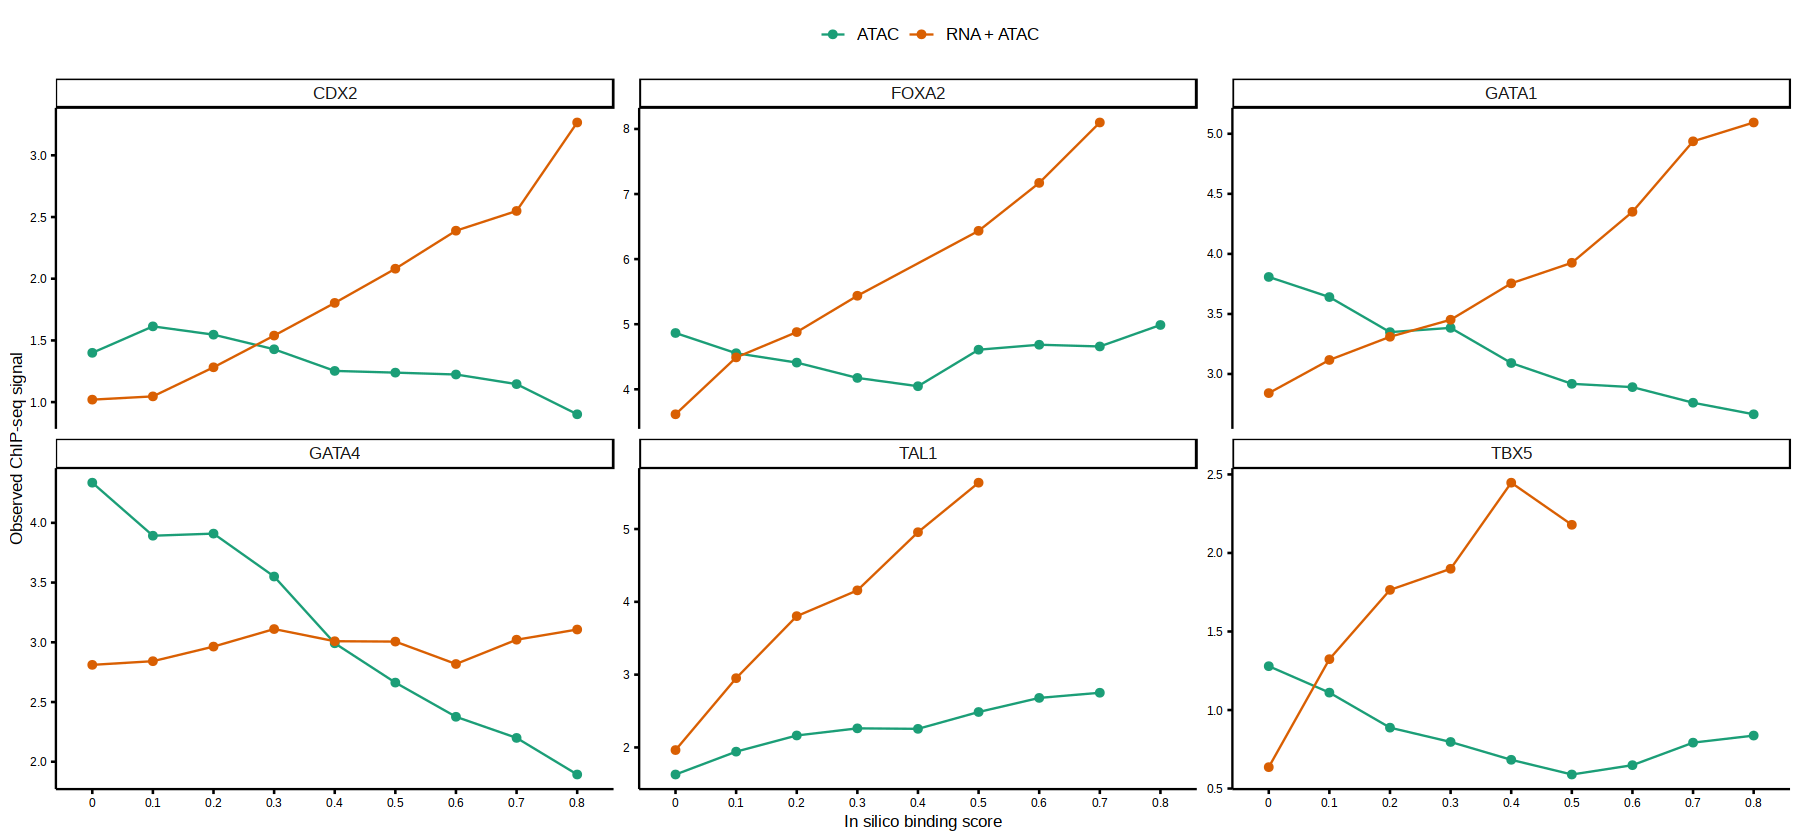

In [50]:
options(repr.plot.width=15, repr.plot.height=7)
ggline(to.plot.compare_models, x="predicted_value", y="mean", color="model", plot_type="b") +
  facet_wrap(~chip_anno, scales="free_y") +
  # geom_errorbar(aes(ymin=log_value-sd, ymax=log_value-sd), width=.2,) +
  scale_color_brewer(palette="Dark2", labels = c("ATAC", "RNA + ATAC")) +
  # scale_color_discrete(labels = c("DNA", "DNA + ATAC", "DNA + ATAC + RNA")) +
  labs(y="Observed ChIP-seq signal", x="In silico binding score") +
  theme(
    strip.background = element_rect(colour="black", fill=NA),
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.8)),
    legend.title = element_blank(),
    # legend.position = c(.26,.87)
    # legend.position = c(.06,.94)
    legend.position = "top"
  )

# search for top Tal1 peak

In [147]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = c('TAL1'),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", 
                          remove_motifs = c("T_789"),
                           cores=1)
b = Sys.time()
b-a

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 6 TFs



FOXA2 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 19.3 GiB”


TAL1 


...

GATA4 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.0 GiB”


GATA1 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.1 GiB”
Warning message in `[.data.table`(., , `:=`(peak, rownames(atac.sce))):
“Invalid .internal.selfref detected and fixed by taking a (shallow) copy of the data.table so that := can add this new column by reference. At an earlier point, this data.table has been copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved.”


Time difference of 6.813757 mins

In [152]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = c("T_789"),
                           cores = 1)

motifmatcher_chip.se = motifmatcher_chip$motifmatcher_chip.se
virtual_chip.dt = motifmatcher_chip$virtual_chip.dt
b = Sys.time()
b-a

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 6"


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.8 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 19.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 11.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 10.6 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.1 GiB”


[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 8.094829 mins